In [22]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 研究监督器

*监督器有一个简单的工作：将研究任务委托给适当数量的子代理。*

这是我们整体的研究流程：

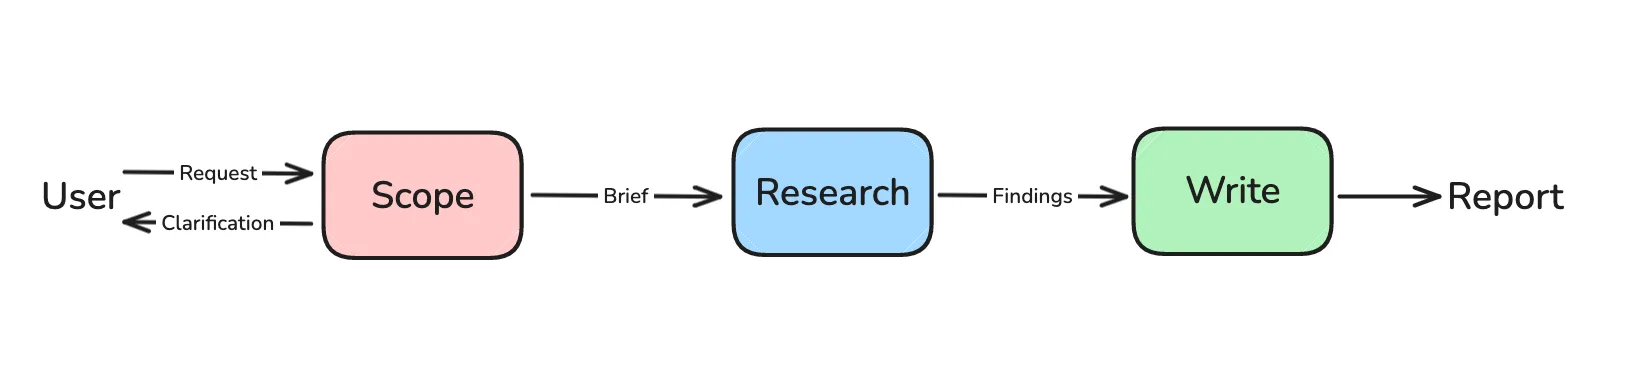

我们之前构建了一个绑定到自定义工具或 MCP 服务器的研究代理。现在，如果请求很复杂并且有几个子主题怎么办？单代理响应质量*可能*会在多个子主题上受到影响（例如，比较 A 与 B 与 C），因为单个上下文窗口需要存储和推理所有子主题的工具反馈。

[许多失败模式](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html)，如[上下文冲突](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html)，随着上下文窗口在许多不同子主题上累积工具调用而变得普遍。正如在[Anthropic的博客文章](https://www.anthropic.com/engineering/built-multi-agent-research-system)中讨论的，多代理系统可以将子主题分配给具有隔离上下文窗口的子代理。我们将构建一个系统，其中监督器确定研究简报是否可以分解为独立的子主题，并委托给具有隔离上下文窗口的子代理。

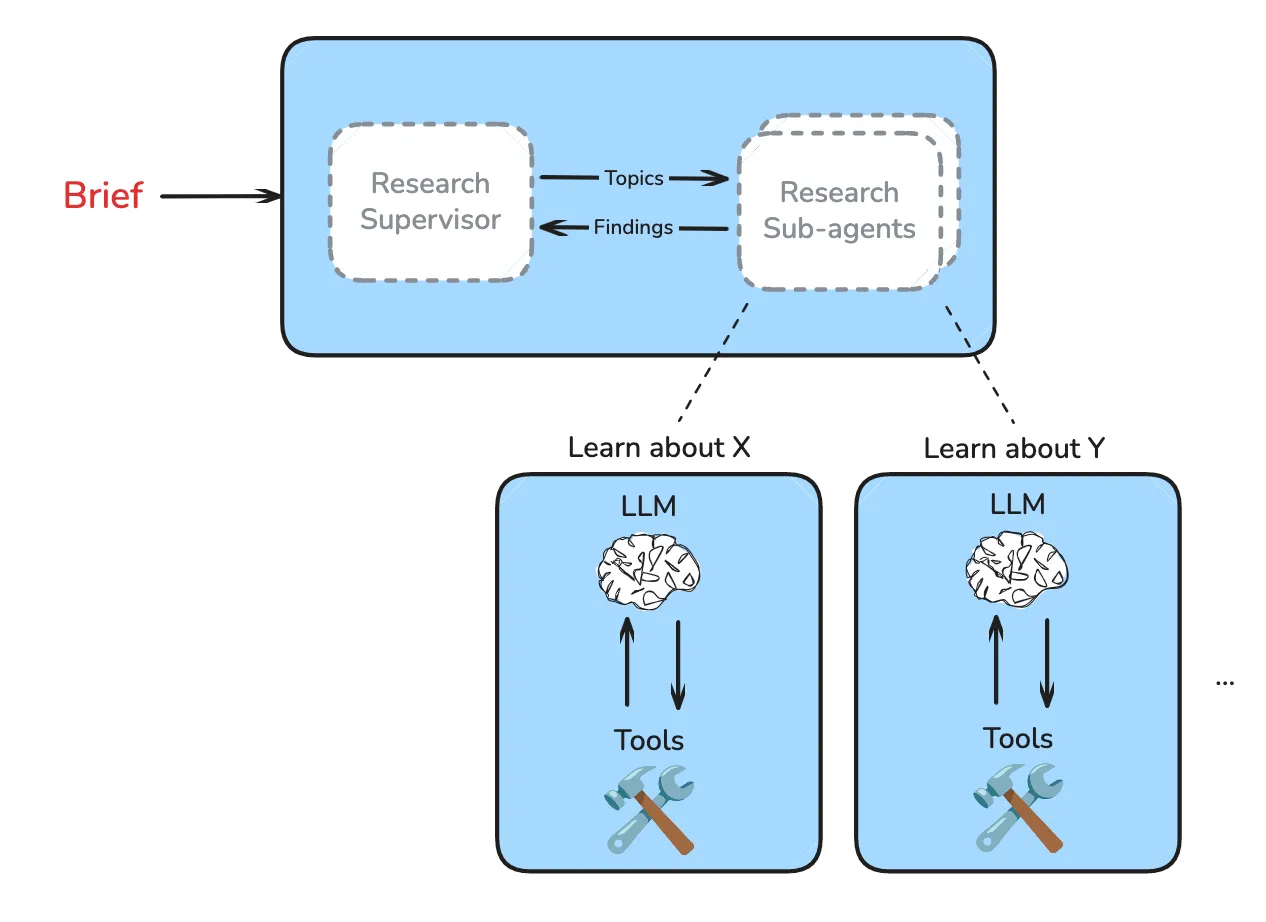

### 提示词

现在，让我们为监督器设计一个遵循我们讨论原则的提示词，并包含[研究文献](https://www.anthropic.com/engineering/built-multi-agent-research-system)的一些见解。

#### 1. 像代理一样思考
你会给新同事什么指示？
- **仔细阅读问题** - 用户需要什么具体信息？
- **决定如何委托研究** - 仔细考虑问题并决定如何委托研究。是否有多个独立方向可以同时探索？
- **在每次调用 ConductResearch 后，暂停并评估** - 我有足够的信息来回答吗？还缺少什么？

#### 2. 具体启发式（用于任务委托）
使用**硬限制**来防止研究代理过度调用工具：
- **偏向单代理** - 除非用户请求有明确的并行化机会，否则使用单代理以保持简单性。
- **在能够自信回答时停止** - 不要为了完美而继续委托研究。
- **限制工具调用** - 如果找不到正确的来源，始终在 3 次 ConductResearch 工具调用后停止。

#### 3. 展示你的思考
在调用 ConductResearch 工具之前，使用 think_tool 来规划你的方法：
- 任务能否分解为更小的子任务？

在每次 ConductResearch 工具调用后，使用 think_tool 来分析结果：
- 我发现了什么关键信息？
- 还缺少什么？
- 我有足够的信息来全面回答问题吗？
- 我应该搜索更多还是提供我的答案？

#### 4. 扩展规则
简单的事实查找、列表和排名可以使用单个子代理。
- *示例*：列出旧金山排名前 10 的咖啡店 -> 使用 1 个子代理

用户请求中提出的比较可以为比较的每个元素使用一个子代理。
- *示例*：比较 OpenAI vs. Anthropic vs. DeepMind 的 AI 安全方法 -> 使用 3 个子代理。
- 委托清晰、独特、不重叠的子主题

In [23]:
from utils import show_prompt
from deep_research_from_scratch.prompts import lead_researcher_prompt
show_prompt(lead_researcher_prompt, "Lead Researcher Prompt")

╭──────────────────────────────────────────── Lead Researcher Prompt ─────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research supervisor. Your job is to conduct research by calling the "ConductResearch" tool. For      │
│  context, today's date is {date}.                                                                               │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your focus is to call the "ConductResearch" tool to conduct research against the overall research question     │
│  passed in by the user.                                                                                         │
│  When you are completely satisfied with the research findings returned from the tool calls, then you should     │
│  call the "ResearchComplete" tool to indicate that you are done with your research.                             │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to three main tools:                                                                           │
│  1. **ConductResearch**: Delegate research tasks to specialized sub-agents                                      │
│  2. **ResearchComplete**: Indicate that research is complete                                                    │
│  3. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool before calling ConductResearch to plan your approach, and after each                │
│  ConductResearch to assess progress**                                                                           │
│  **PARALLEL RESEARCH**: When you identify multiple independent sub-topics that can be explored simultaneously,  │
│  make multiple ConductResearch tool calls in a single response to enable parallel research execution. This is   │
│  more efficient than sequential research for comparative or multi-faceted questions. Use at most                │
│  {max_concurrent_research_units} parallel agents per iteration.                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a research manager with limited time and resources. Follow these steps:                             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the    │
│  research. Are there multiple independent directions that can be explored simultaneously?                       │
│  3. **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still         │
│  missing?                                                                                                       │
│  </Instructions>                                      

### 状态

监督器状态管理整体研究协调，而研究员状态处理个别研究任务。

In [ ]:
%%writefile ../src/deep_research_from_scratch/state_multi_agent_supervisor.py

"""
多代理研究监督器的状态定义

此模块定义了多代理研究监督器工作流程中使用的状态对象和工具，
包括协调状态和研究工具。
"""

import operator
from typing_extensions import Annotated, TypedDict, Sequence

from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

class SupervisorState(TypedDict):
    """
    多代理研究监督器的状态。
    
    管理监督器和研究代理之间的协调，跟踪研究进度
    并累积来自多个子代理的发现。
    """
    
    # 与监督器交换的消息，用于协调和决策
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]
    # 指导整体研究方向的详细研究简报
    research_brief: str
    # 为最终报告生成准备的已处理和结构化笔记
    notes: Annotated[list[str], operator.add] = []
    # 跟踪已执行研究迭代次数的计数器
    research_iterations: int = 0
    # 从子代理研究中收集的原始未处理研究笔记
    raw_notes: Annotated[list[str], operator.add] = []

@tool
class ConductResearch(BaseModel):
    """将研究任务委托给专门子代理的工具。"""
    research_topic: str = Field(
        description="要研究的主题。应该是单一主题，并且应该详细描述（至少一段话）。",
    )

@tool
class ResearchComplete(BaseModel):
    """表示研究过程已完成的工具。"""
    pass

### 多代理 

现在，我们将定义我们的代理。多代理系统是由多个代理协同工作完成任务的系统。正如在[代理的上下文工程](https://blog.langchain.com/context-engineering-for-agents/)中讨论的，主要好处是上下文隔离。

In [ ]:
%%writefile ../src/deep_research_from_scratch/multi_agent_supervisor.py

"""用于协调多个专门代理研究的多代理监督器。

此模块实现监督器模式，其中：
1. 监督器代理协调研究活动并委托任务
2. 多个研究员代理独立工作于特定子主题
3. 结果被聚合和压缩用于最终报告

监督器使用并行研究执行来提高效率，同时
为每个研究主题保持隔离的上下文窗口。
"""

import asyncio

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage, 
    BaseMessage, 
    SystemMessage, 
    ToolMessage,
    filter_messages
)
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

from deep_research_from_scratch.prompts import lead_researcher_prompt
from deep_research_from_scratch.research_agent import researcher_agent
from deep_research_from_scratch.state_multi_agent_supervisor import (
    SupervisorState, 
    ConductResearch, 
    ResearchComplete
)
from deep_research_from_scratch.utils import get_today_str, think_tool

def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """从监督器消息历史中的 ToolMessage 对象提取研究笔记。
    
    此函数检索子代理作为 ToolMessage 内容返回的压缩研究发现。
    当监督器通过 ConductResearch 工具调用将研究委托给子代理时，
    每个子代理将其压缩发现作为 ToolMessage 的内容返回。
    此函数提取所有此类 ToolMessage 内容以编制最终研究笔记。
    
    Args:
        messages: 来自监督器对话历史的消息列表
        
    Returns:
        从 ToolMessage 对象提取的研究笔记字符串列表
    """
    return [tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")]

# 确保 Jupyter 环境的异步兼容性
try:
    import nest_asyncio
    # 仅在 Jupyter/IPython 环境中运行时应用
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass  # 不在 Jupyter 中，不需要 nest_asyncio
except ImportError:
    pass  # nest_asyncio 不可用，继续执行而不使用它


# ===== 配置 =====

supervisor_tools = [ConductResearch, ResearchComplete, think_tool]
supervisor_model = init_chat_model(model="anthropic:claude-sonnet-4-20250514")
supervisor_model_with_tools = supervisor_model.bind_tools(supervisor_tools)

# 系统常量
# 单个研究员代理的最大工具调用迭代次数
# 这防止无限循环并控制每个主题的研究深度
max_researcher_iterations = 6 # 对 think_tool + ConductResearch 的调用

# 监督器可以启动的最大并发研究代理数
# 这传递给 lead_researcher_prompt 以限制并行研究任务
max_concurrent_researchers = 3

# ===== 监督器节点 =====

async def supervisor(state: SupervisorState) -> Command[Literal["supervisor_tools"]]:
    """协调研究活动。
    
    分析研究简报和当前进度以决定：
    - 需要调查哪些研究主题
    - 是否进行并行研究
    - 何时完成研究
    
    Args:
        state: 当前监督器状态，包含消息和研究进度
        
    Returns:
        继续到 supervisor_tools 节点并更新状态的命令
    """
    supervisor_messages = state.get("supervisor_messages", [])
    
    # 准备包含当前日期和约束的系统消息
    system_message = lead_researcher_prompt.format(
        date=get_today_str(), 
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_researcher_iterations
    )
    messages = [SystemMessage(content=system_message)] + supervisor_messages
    
    # 对下一步研究步骤做出决定
    response = await supervisor_model_with_tools.ainvoke(messages)
    
    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1
        }
    )

async def supervisor_tools(state: SupervisorState) -> Command[Literal["supervisor", "__end__"]]:
    """执行监督器决策 - 要么进行研究要么结束过程。
    
    处理：
    - 执行 think_tool 调用以进行战略反思
    - 为不同主题启动并行研究代理
    - 聚合研究结果
    - 确定研究何时完成
    
    Args:
        state: 当前监督器状态，包含消息和迭代计数
        
    Returns:
        继续监督、结束过程或处理错误的命令
    """
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]
    
    # 为单一返回模式初始化变量
    tool_messages = []
    all_raw_notes = []
    next_step = "supervisor"  # 默认下一步
    should_end = False
    
    # 首先检查退出条件
    exceeded_iterations = research_iterations >= max_researcher_iterations
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tool_call["name"] == "ResearchComplete" 
        for tool_call in most_recent_message.tool_calls
    )
    
    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END
    
    else:
        # 在决定下一步之前执行所有工具调用
        try:
            # 将 think_tool 调用与 ConductResearch 调用分开
            think_tool_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "think_tool"
            ]
            
            conduct_research_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "ConductResearch"
            ]

            # 处理 think_tool 调用（同步）
            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call["args"])
                tool_messages.append(
                    ToolMessage(
                        content=observation,
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    )
                )

            # 处理 ConductResearch 调用（异步）
            if conduct_research_calls:
                # 启动并行研究代理
                coros = [
                    researcher_agent.ainvoke({
                        "researcher_messages": [
                            HumanMessage(content=tool_call["args"]["research_topic"])
                        ],
                        "research_topic": tool_call["args"]["research_topic"]
                    }) 
                    for tool_call in conduct_research_calls
                ]

                # 等待所有研究完成
                tool_results = await asyncio.gather(*coros)

                # 将研究结果格式化为工具消息
                # 每个子代理在 result["compressed_research"] 中返回压缩的研究发现
                # 我们将此压缩研究写作为 ToolMessage 的内容，这允许
                # 监督器稍后通过 get_notes_from_tool_calls() 检索这些发现
                research_tool_messages = [
                    ToolMessage(
                        content=result.get("compressed_research", "合成研究报告时出错"),
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    ) for result, tool_call in zip(tool_results, conduct_research_calls)
                ]
                
                tool_messages.extend(research_tool_messages)

                # 聚合所有研究的原始笔记
                all_raw_notes = [
                    "\n".join(result.get("raw_notes", [])) 
                    for result in tool_results
                ]
                
        except Exception as e:
            print(f"监督器工具中的错误: {e}")
            should_end = True
            next_step = END
    
    # 带有适当状态更新的单一返回点
    if should_end:
        return Command(
            goto=next_step,
            update={
                "notes": get_notes_from_tool_calls(supervisor_messages),
                "research_brief": state.get("research_brief", "")
            }
        )
    else:
        return Command(
            goto=next_step,
            update={
                "supervisor_messages": tool_messages,
                "raw_notes": all_raw_notes
            }
        )

# ===== 图构建 =====

# 构建监督器图
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)
supervisor_builder.add_edge(START, "supervisor")
supervisor_agent = supervisor_builder.compile()

In [ ]:
from IPython.display import Image, display
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# 显示代理
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# 运行多代理监督器代理
from utils import format_messages
from langchain_core.messages import HumanMessage

research_brief = """我想识别和评估旧金山被认为是最好的咖啡店，特别是基于咖啡质量。我的研究应该专注于分析和比较旧金山地区的咖啡店，
以咖啡质量作为主要标准。我对评估咖啡质量的方法持开放态度（例如，专家评论、客户评分、特色咖啡认证），除非它们直接影响感知的咖啡质量，
否则对氛围、位置、wifi或食物选择没有限制。请优先考虑主要来源，如咖啡店的官方网站、知名的第三方咖啡评论组织（如Coffee Review或
Specialty Coffee Association），以及可以找到关于咖啡质量的直接客户反馈的重要评论聚合器如Google或Yelp。该研究应该产生一个
有充分支持的旧金山顶级咖啡店列表或排名，根据截至2025年7月的最新可用数据强调它们的咖啡质量。"""

result = await supervisor_agent.ainvoke({"supervisor_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['supervisor_messages'])

我们可以在[这里](https://smith.langchain.com/public/99eaaecd-fd9a-4ead-8eed-abdfe4ab9288/r)查看跟踪。

### LangGraph Studio

就像我们之前做的那样，我们也可以使用 LangGraph Studio 来可视化代理。

此代理已添加到 `langgraph.json` 文件中，因此您可以在下拉菜单中选择 `research_agent_supervisor`：

```
"research_agent_supervisor": "./src/deep_research_from_scratch/multi_agent_supervisor.py:supervisor_agent",
```

运行以下命令启动 studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## 评估

多代理的明显好处是当有明确可分离的子主题时的上下文隔离。正如我们在[我们的博客](https://blog.langchain.com/open-deep-research/)中讨论的：

> 我们的实验表明，如果请求有多个子主题（例如，比较 A 与 B 与 C），单代理响应质量会受到影响。这里的直觉很简单：单个上下文窗口需要存储和推理所有子主题的工具反馈。这种工具反馈通常是词汇量很大的。随着上下文窗口在许多不同子主题上累积工具调用，许多失败模式（如上下文冲突）变得普遍。

但是，我们要小心不要在不需要的情况下生成子代理：

> 监督器可以通过选择性地生成子代理来调整请求所需的研究深度来处理这两种情况。监督器被提示使用启发式方法来推理何时应该并行化研究，何时单线程研究就足够了。我们的深度研究代理具有选择是否并行化研究的灵活性。

让我们设置一些测试，以确保我们在有意义时进行并行化。

In [ ]:
# 用于评估的包含 think_tool 调用和工具消息的示例消息
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

should_parallelize = [
    HumanMessage(content="比较 OpenAI vs Gemini 深度研究。"),
    AIMessage(content="我需要分析这个请求以确定是否应该并行化。", tool_calls=[
        {
            "name": "think_tool",
            "args": {"reflection": "这是一个涉及两个不同 AI 产品的比较任务：OpenAI vs Gemini 深度研究。"},
            "id": "call_think_1"
        }
    ]),
    ToolMessage(content="分析完成：这是一个涉及两个不同 AI 产品的比较任务：OpenAI vs Gemini 深度研究。", tool_call_id="call_think_1", name="think_tool")
]

should_not_parallelize = [
    HumanMessage(content="曼哈顿切尔西排名前三的中餐厅是什么"),
    AIMessage(content="让我思考一下这个任务是否需要并行化。", tool_calls=[
        {
            "name": "think_tool", 
            "args": {"reflection": "这是一个针对特定地理区域（曼哈顿切尔西）餐厅的排名/列表任务。"},
            "id": "call_think_2"
        }
    ]),
    ToolMessage(content="分析完成：这是一个针对特定地理区域（曼哈顿切尔西）餐厅的排名/列表任务。", tool_call_id="call_think_2", name="think_tool")
]

In [ ]:
import os
from langsmith import Client

# 初始化客户端
langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# 创建数据集
dataset_name = "deep_research_supervisor_parallelism"
if not langsmith_client.has_dataset(dataset_name=dataset_name):

    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="评估监督器是否能准确决定何时并行化研究的数据集。",
    )

    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"supervisor_messages": should_parallelize},
                "outputs": {"num_expected_threads": 2},
            },
            {
                "inputs": {"supervisor_messages": should_not_parallelize},
                "outputs": {"num_expected_threads": 1},
            },
        ],
    )

现在我们可以运行评估。

In [ ]:
import uuid

def evaluate_parallelism(outputs: dict, reference_outputs:dict):
    tool_calls = outputs["output"].update["supervisor_messages"][-1].tool_calls
    return {
        "key": "correct_next_step",
        "score": len(tool_calls) == reference_outputs["num_expected_threads"]
    }

async def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    return await supervisor_agent.nodes["supervisor"].ainvoke(inputs, config=config)

await langsmith_client.aevaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_parallelism],
    experiment_prefix="监督器并行化",
)

在第一个示例中，我们要求代理比较和对比产品。

这种类型的问题非常适合并行研究，我们期望代理在撰写报告时综合发现之前，并行深入研究每个实验室。

第二个示例要求代理列出曼哈顿切尔西的顶级餐厅。

代理需要在这里进行单线程研究，并反思可能列出高评级餐厅的网站。

对于这个排名任务，没有明显的并行化机会。